In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path                          
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
# Load dataset
df = pd.read_excel(r"C:\Users\User\OneDrive\Documents\Brazilian-Ecommerce-Cleaned.xlsx", parse_dates=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
print("Done!")

Done!


=== Delay Days Distribution ===
count    110361.000000
mean        -11.467756
std           8.643747
min         -30.000000
25%         -17.000000
50%         -12.000000
75%          -7.000000
max          60.000000
Name: delay_days, dtype: float64

Early (<-5 days):     91357
On-time (-5 to 2):    13238
Late (>2 days):       5766

Sampling 5766 records from each group (17298 total)
=== Model Performance ===
R²:   0.1416
MAE:  8.3821 days
RMSE: 11.3326 days

=== Sample Predictions ===
 Actual_Delay_Days  Predicted_Delay_Days
                -3                   4.4
                43                   1.9
                -7                  -2.2
                -1                  -0.6
                 7                  -0.1
                 1                  -2.2
                 6                   1.3
               -18                  -9.1
               -15                  -7.4
               -14                   5.7


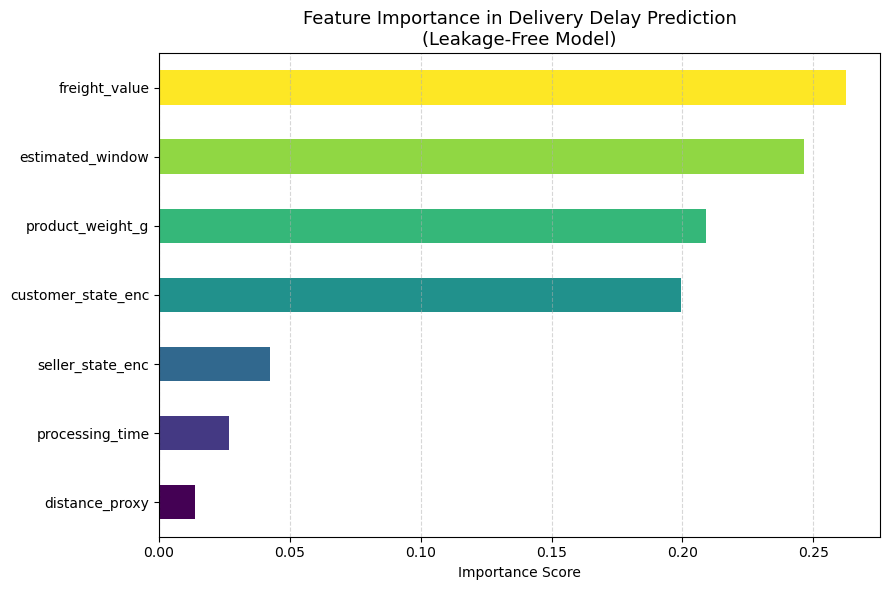

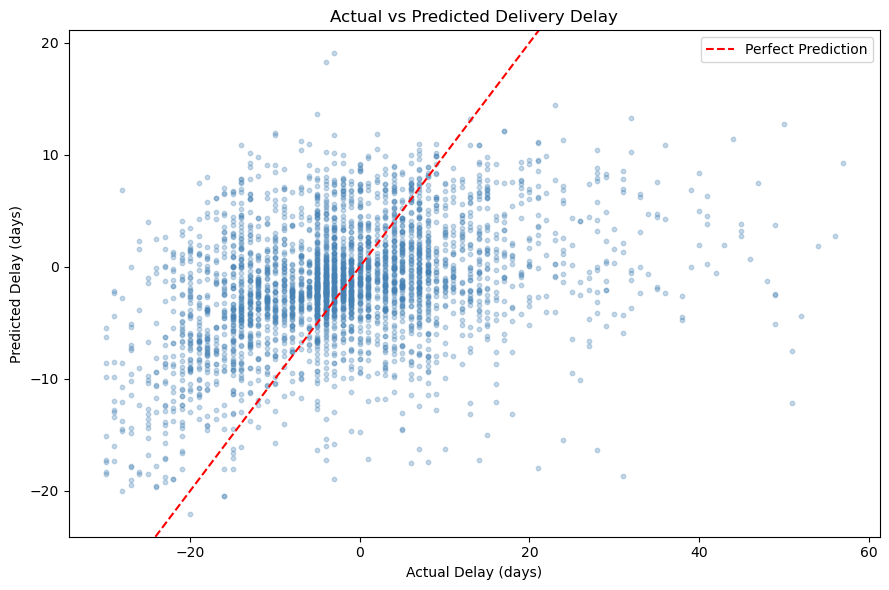

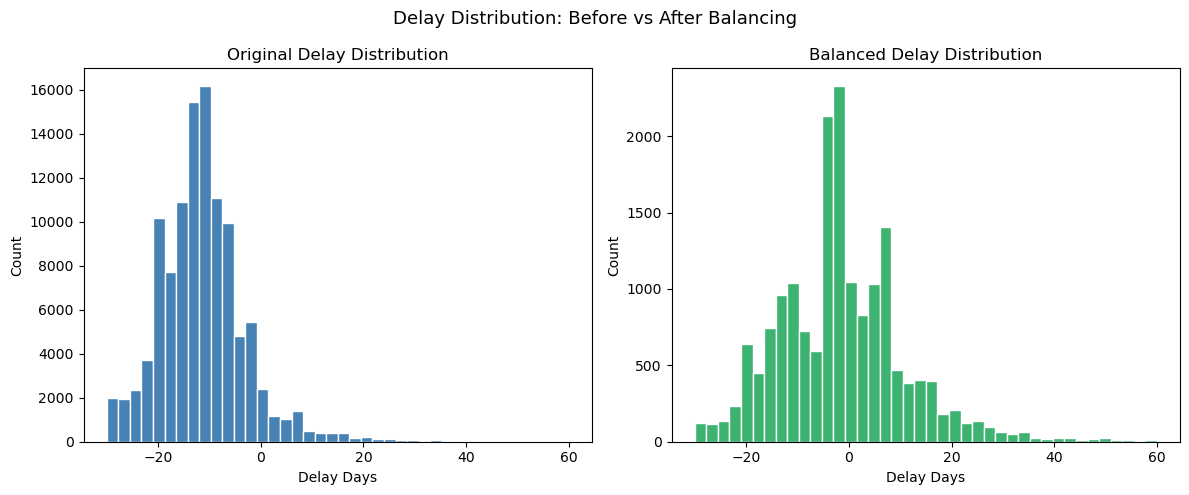

In [4]:
# ============================================================
# MODEL 1: DELIVERY DELAY ANALYSIS
# Random Forest Regressor — Leakage-Free, Balanced Version
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel(r"C:\Users\User\OneDrive\Documents\Brazilian-Ecommerce-Cleaned.xlsx")

# ============================================================
# DATE & FEATURE ENGINEERING
# ============================================================

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

df[date_cols] = df[date_cols].apply(pd.to_datetime)

# Target variable
df["delay_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days

# Pre-delivery features only
df["processing_time"] = (
    df["order_approved_at"] -
    df["order_purchase_timestamp"]
).dt.days

df["estimated_window"] = (
    df["order_estimated_delivery_date"] -
    df["order_purchase_timestamp"]
).dt.days

df["distance_proxy"] = (
    df["seller_state"] != df["customer_state"]
).astype(int)

# Encode state columns
le = LabelEncoder()
df["seller_state_enc"] = le.fit_transform(df["seller_state"].astype(str))
df["customer_state_enc"] = le.fit_transform(df["customer_state"].astype(str))

# ============================================================
# CLEAN DATA
# ============================================================

df = df.dropna(subset=[
    "delay_days", "processing_time", "estimated_window",
    "freight_value", "product_weight_g",
    "distance_proxy", "seller_state_enc", "customer_state_enc"
])

df = df[df["delay_days"].between(-30, 60)]
df = df[df["processing_time"] >= 0]
df = df[df["estimated_window"] > 0]

# ============================================================
# CHECK DISTRIBUTION BEFORE BALANCING
# ============================================================

print("=== Delay Days Distribution ===")
print(df["delay_days"].describe())
print()

early  = df[df["delay_days"] < -5]
ontime = df[(df["delay_days"] >= -5) & (df["delay_days"] <= 2)]
late   = df[df["delay_days"] > 2]

print(f"Early (<-5 days):     {len(early)}")
print(f"On-time (-5 to 2):    {len(ontime)}")
print(f"Late (>2 days):       {len(late)}")
print()

# ============================================================
# BALANCE THE DATASET
# ============================================================

n = min(len(early), len(ontime), len(late), 8000)
print(f"Sampling {n} records from each group ({n*3} total)")

df_balanced = pd.concat([
    early.sample(n, random_state=42),
    ontime.sample(n, random_state=42),
    late.sample(n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# ============================================================
# FEATURES & TARGET
# ============================================================

feature_cols = [
    "processing_time",
    "estimated_window",
    "freight_value",
    "product_weight_g",
    "distance_proxy",
    "seller_state_enc",
    "customer_state_enc"
]

X = df_balanced[feature_cols]
y = df_balanced["delay_days"]

# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# MODEL
# ============================================================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ============================================================
# EVALUATION METRICS
# ============================================================

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Model Performance ===")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f} days")
print(f"RMSE: {rmse:.4f} days")
print()

# ============================================================
# ACTUAL VS PREDICTED TABLE
# ============================================================

results = pd.DataFrame({
    "Actual_Delay_Days":    y_test.values,
    "Predicted_Delay_Days": y_pred.round(1)
})

print("=== Sample Predictions ===")
print(results.head(10).to_string(index=False))

output_dir = Path("D:\Olist_Analysis_Project\Outputs")  #Path for saved images
output_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# PLOT 1 — FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(9, 6))
importance.plot(
    kind="barh",
    color=plt.cm.viridis(np.linspace(0, 1, len(importance)))
)
plt.title("Feature Importance in Delivery Delay Prediction\n(Leakage-Free Model)", 
          fontsize=13)
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir / "feature_importance.png", dpi=300)
plt.show()

# ============================================================
# PLOT 2 — ACTUAL VS PREDICTED SCATTER
# ============================================================

plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.axline((0, 0), slope=1, color='red', linestyle='--',
           label='Perfect Prediction')
plt.xlabel("Actual Delay (days)")
plt.ylabel("Predicted Delay (days)")
plt.title("Actual vs Predicted Delivery Delay")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir /"actual_vs_predicted_corrected.png", dpi=300)
plt.show()

# ============================================================
# PLOT 3 — DELAY DISTRIBUTION (Before & After Balancing)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["delay_days"], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Original Delay Distribution")
axes[0].set_xlabel("Delay Days")
axes[0].set_ylabel("Count")

axes[1].hist(df_balanced["delay_days"], bins=40, 
             color='mediumseagreen', edgecolor='white')
axes[1].set_title("Balanced Delay Distribution")
axes[1].set_xlabel("Delay Days")
axes[1].set_ylabel("Count")

plt.suptitle("Delay Distribution: Before vs After Balancing", fontsize=13)
plt.tight_layout()
plt.savefig(output_dir /"delay_distribution.png", dpi=300)
plt.show()